# Klasyfikator w dwie minuty

![image.png](attachment:398990fb-d542-418f-9f8a-884e1c0de641.png)

W trakcie tej olimpiady przyszło Ci się zmierzyć z różnym typem danych, m.in. z obrazami i tekstem. Ale czy zastanawiałaś/eś, na jakiej podstawie telefony lub opaski sportowe wiedzą o tym, jaką aktywność aktualnie wykonujecie?

W Twoim telefonie znajdują się rozmaite sensory, w tym akcelerometr, żyroskop, a nawet barometr. Na podstawie sygnałów pochodzących z tych urządzeń (mierzonych w pewnym okresie) telefon jest w stanie rozpoznać aktywność użytkownika.

Tego typu dane nazywamy **(wielowymiarowymi) szeregami czasowymi**, ponieważ w ustalonej chwili otrzymujemy dane w kilku wymiarach, np. z różnych osi akcelerometru.

W rzeczywistości etykietowanie danych jest kosztowne i wymaga wiedzy eksperta, dlatego zazwyczaj jedynie część danych posiada etykiety, zaś przyporządkowanie etykiet dla reszty danych wykonywane jest automatycznie.

Self-supervised learning to technika polegająca na nauce reprezentacji danych bez użycia ich etykiet. Wyuczone reprezentacje, nazywane ukrytymi (latents), są zazwyczaj osadzone w niżej wymiarowej przestrzeni oraz dobrze reprezentują dane wejściowe. Są one później wykorzystywane w tzw. downstream taskach, np. klasyfikacji, w której uczymy model na reprezentacjach ukrytych, a nie na oryginalnych danych.

## Pliki

- `train_x_big.pt` - pomiary pochodzące z czujników; mają one posłużyć za zbiór treningowy, ale nie dysponujemy etykietami dla tych danych;
- `train_x_small.pt`- mały podzbiór zbioru treningowego, do którego elementów posiadamy etykiety;
- `train_y_small.pt` - etykiety dla podzbioru pomiarów zawartych w `train_x_small.pt`;
- `val_x.pt` - pomiary pochodzące z czujników, które mają posłużyć za zbiór walidacyjny;
- `val_y.pt` - etykiety dla danych w zbiorze walidacyjnym zawartych w `val_x.pt`.

### Zadanie
Twoim zadaniem jest:
1. Wytrenowanie modelu w trybie self-supervised, uczącego się ogólnej reprezentacji danych treningowych (`train_x_big.pt`) bez informacji o klasach;
2. Zaimplementowanie metody `finetune_and_predict` trenującej klasyfikator, którego danymi wejściowymi są zanurzenia (embeddingi) szeregów czasowych z pliku `train_x_small.pt`, uzyskane za pomocą modelu self-supervised z punktu pierwszego. Metoda musi zwracać numer wybranej klasy dla zadanego szeregu, zaś nie ich reprezentację gorącojedynkową (ang. *one-hot encoding*).

W trakcie testowania rozwiązań `train_y_small.pt` będzie miał inne klasy niż ten załączony do zadania. Będzie ich jednak ta sama liczba. Można myśleć o tym w ten sposób, że mamy tutaj klasy {"pieszo", "samochód"}, natomiast przy ewaluacji model będzie finetunowany na zbiorze etykiet {"rower", "pływanie"}.

### Ocenianie
Jakość zaproponowanego rozwiązania będzie zweryfikowana w postaci wyliczenia accuracy na zbiorze testowym, który dostępny jest jedynie dla organizatorów. Zbiór testowy jest zbalansowany, a zawarte w nim szeregi czasowe cechują się charakterystykami porównywalnymi do zbioru walidacyjnego.

Za to zadanie możesz zdobyć pomiędzy 0 i 1 punktów. Zdobędziesz 0 punktów jeśli dokładność klasyfikacji na zbiorze testowym wyniesie poniżej 70%, a 1 punkt jeśli wyniesie powyżej 90%. Pomiędzy tymi wartościami, wynik rośnie liniowo z wartością kryterium.

### Pliki zgłoszeniowe
- Ten notebook
- Wagi modelu (`encoder.pt`)

### Ograniczenia

Ewaluacja twojego rozwiązania (bez treningu, flaga `FINAL_EVALUATION_MODE` ustawiona na `True`) powinna trwać nie dłużej niż 2 minuty na Google Colab z GPU T4.
Wykonanie skryptu na Google Colab z GPU z flagą `FINAL_EVALUATION_MODE` ustawioną na `False` powinno wytrenować model i wygenerować plik z wagami w czasie nie dłuższym niż 10 minut.
Rozmiar pliku `encoder.pt` nie powinien przekroczyć 10MB.

In [1]:
FINAL_EVALUATION_MODE = False

Poniżej zapewniono kod do zapisywania oraz ewaluacji modelu, a także ładowania danych. Możesz, ale nie musisz z niego korzystać.

Poniższe klasy oraz metody można dowolnie modyfikować, należy jedynie pamiętać aby metoda `finetune_and_predict()` przyjmowała cztery argumenty `(X_train_small, y_train_small, X_test, model_path)`

## Kod startowy

Na początek zaimportujmy wszystkie niezbędne biblioteki, zdefiniujmy instancje klas obsługujące dane (`DataLoader`), niezbędne hiperparametry oraz funkcję do zapisywania modeli.

In [2]:
import os
import random
import warnings

import gdown
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [3]:
# NIE ZMIENIAJ TYCH WARTOŚCI
DEVICE = torch.device("cuda")
MODEL_FP = "./encoder.pt"

In [4]:
class CustomTensorDataset(Dataset):
    """TensorDataset with support of transforms."""
    def __init__(self, data, transform_A=None, transform_B=None):
        assert all(data[0].shape[0] == item.shape[0] for item in data)
        self.data = data
        self.transform_A = transform_A
        self.transform_B = transform_B

    def __getitem__(self, index):
        x = self.data[0][index]

        if self.transform_A:
            x1 = self.transform_A(x)
        else:
            x1 = x
        if self.transform_B:
            x2 = self.transform_B(x)
        else:
            x2 = x
        y = self.data[1][index]

        return torch.tensor(x1).float(), torch.tensor(x2).float(), torch.tensor(y)

    def __len__(self):
        return self.data[0].shape[0]

In [5]:
def setup_seed(seed=42):
    """Setup seed for the reproducipility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

## Szkielet rozwiązania

### Modele: encoder i klasyfikator

Poniżej zaimplementowano przykładowe (i niezbyt skuteczne) rozwiązanie zadania. Zaprezentowany został prosty enkoder, którego celem jest stworzenie użytecznej reprezentacji danych wykorzystywanej później przez prosty klasyfikator typu perceptron wielowarstwowy.

In [6]:
# TE WARTOŚCI MOŻNA ZMIENIAĆ
seed =  42
enc_epochs = 200
n_class = 6
n_channel = 3

latent_chns = 40

log_batch_size = 48
log_epochs = 110

In [7]:
class DownBlock(nn.Module):
    def __init__(self, chns_from, chns_to, pad):
        super(DownBlock, self).__init__()

        self.md = nn.Sequential(
            nn.Conv1d(chns_from + 1, chns_from, 3, 1, pad),
            # nn.BatchNorm1d(chns_from),
            nn.LeakyReLU(0.04),

            nn.Conv1d(chns_from, chns_from, 4, 2, 0),
            nn.BatchNorm1d(chns_from),
            nn.LeakyReLU(0.08),

            nn.Conv1d(chns_from, chns_to, 3, 1, 0),
            nn.LeakyReLU(0.08),

            nn.Conv1d(chns_from, chns_to, 3, 1, 1),
            nn.LeakyReLU(0.08)
        )

    def forward(self, x):
        ln = torch.linspace(0, 1, x.shape[2], device=x.device, dtype=x.dtype)
        ln = ln.view(1, 1, -1).repeat((x.shape[0], 1, 1))
        x = torch.cat([ln, x], dim=1)
        return self.md(x)

class UpBlock(nn.Module):
    def __init__(self, chns_from, chns_to, pad):
        super(UpBlock, self).__init__()

        self.md = nn.Sequential(
            nn.Conv1d(chns_from + 1, chns_to, 3, 1, pad),
            # nn.BatchNorm1d(chns_to),
            nn.LeakyReLU(0.04),

            nn.ConvTranspose1d(chns_to, chns_to, 4, 2, 1),
            nn.BatchNorm1d(chns_to),
            nn.LeakyReLU(0.08),

            nn.Conv1d(chns_to, chns_to, 3, 1, 0),
            nn.LeakyReLU(0.08),

            nn.Conv1d(chns_to, chns_to, 3, 1, 1),
            nn.LeakyReLU(0.08)
        )

    def forward(self, x):
        # (batch_size, channels, len)
        ln = torch.linspace(0, 1, x.shape[2], device=x.device, dtype=x.dtype)
        ln = ln.view(1, 1, -1).repeat((x.shape[0], 1, 1))
        x = torch.cat([ln, x], dim=1)
        return self.md(x)

class Encoder(nn.Module):
    def __init__(self, latent_chns, n_channel):
        super(Encoder, self).__init__()

        self.md = nn.Sequential(
            nn.Conv1d(n_channel, 64, 3, 1, padding='same'), # 206 -> 206
            nn.LeakyReLU(0.3),
            DownBlock(64, 64, 1), # 206 -> 100
            DownBlock(64, 64, 0), # 100 -> 46
            DownBlock(64, 64, 1), # 46 -> 20
            DownBlock(64, 64, 0), # 20 -> 6
            nn.Conv1d(64, latent_chns, 3, 1, 1)
        )

    def forward(self, x):
        return self.md(x)

class Decoder(nn.Module):
    def __init__(self, latent_chns, n_channel):
        super(Decoder, self).__init__()

        self.md = nn.Sequential(
            UpBlock(latent_chns, 64, 1),
            UpBlock(64, 64, 1),
            UpBlock(64, 64, 0),
            UpBlock(64, 64, 0),
            UpBlock(64, 64, 1),
            UpBlock(64, 64, 0),
            nn.Conv1d(64, n_channel, 3, 1, 1),
        )

    def forward(self, x):
        return self.md(x)

class AutoEncoder(nn.Module):
    def __init__(self, latent_chns, n_channel):
        super(AutoEncoder, self).__init__()

        self.encoder = Encoder(latent_chns, n_channel)
        self.decoder = Decoder(latent_chns, n_channel)
        self.prm = nn.Parameter(torch.randn((1, 3, 206)), requires_grad=True)

    def forward(self, x):
        flt = x.squeeze(dim=1)
        res = flt
        res = self.encoder(res)
        res = self.decoder(res)
        return res, flt

    def encode(self, x):
        flt = x.squeeze(dim=1)
        return self.encoder(flt)

    def save_model(self, model):
        torch.save(model.state_dict(), MODEL_FP)

In [8]:
class MLPClassifier(nn.Module):
    def __init__(self, n_classes):
        super(MLPClassifier, self).__init__()

        n_features = latent_chns * 6

        self.model = nn.Sequential(
            nn.Linear(n_features, 48),
            nn.BatchNorm1d(48),
            nn.LeakyReLU(0.05),

            nn.Linear(48, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.04),

            nn.Linear(32, 24),
            nn.BatchNorm1d(24),
            nn.LeakyReLU(0.03),

            nn.Linear(24, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.03),

            nn.Linear(16, 16),
            nn.LeakyReLU(0.03),

            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        return self.model(x)

### Trening encodera
Jeżeli chcemy wytrenować enkoder, możemy skorzystać z poniższej funkcji. W naszym niezbyt skutecznym rozwiązaniu zostawiamy go z losowymi wagami.

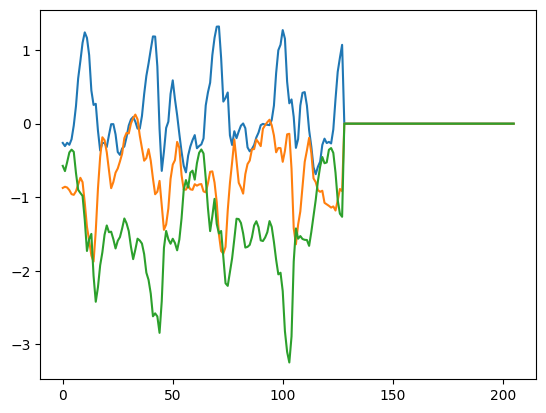

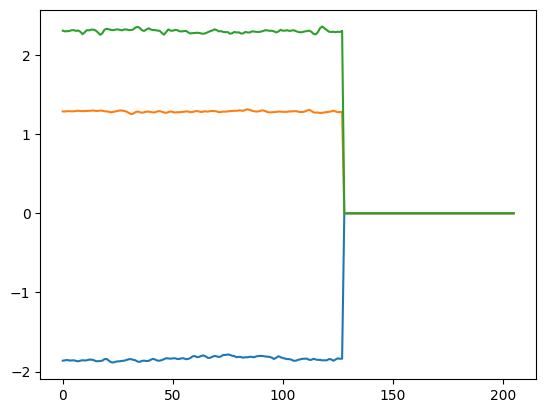

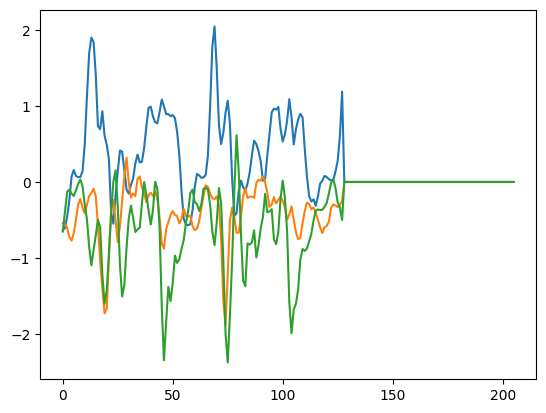

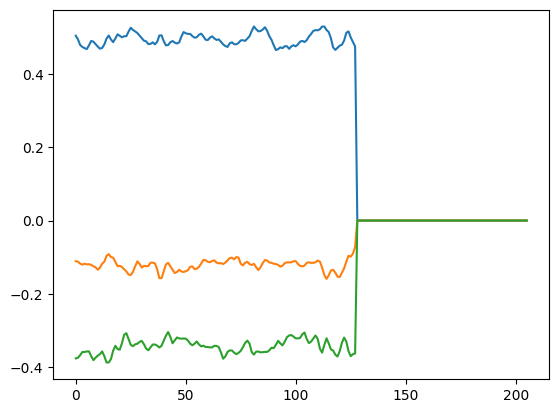

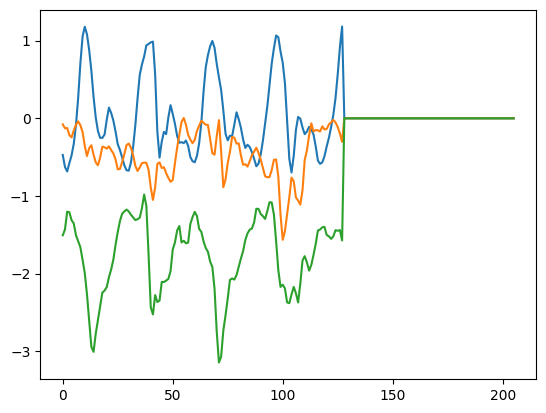


loss: 0.2986

loss: 0.0518

loss: 0.0432

loss: 0.0378

loss: 0.0355

loss: 0.0289

loss: 0.0224


In [9]:
def train(unlabelled_train_loader, autoencoder_model):
    optimizer = torch.optim.Adam(autoencoder_model.parameters(), 0.0004, (0.93, 0.99))
    for epoch in range(enc_epochs):
        loss_epoch = []
        for step, x_i in enumerate(unlabelled_train_loader):
            optimizer.zero_grad()
            x_i = x_i.to(DEVICE, dtype=torch.float)

            df, flt = autoencoder_model(x_i)

            loss = ((flt - df) ** 2).mean()
            loss.backward()
            optimizer.step()
            loss_epoch.append(loss.item())
        if epoch % 30 == 0:
            print(f"\nloss: {sum(loss_epoch) / len(loss_epoch):.4f}")

if not FINAL_EVALUATION_MODE:
    X_train_big = torch.load("train_x_big.pt")
    for i in range(5):
        for channel in X_train_big[i, 0]:
            plt.plot(channel)
        plt.show()
    dataloader = torch.utils.data.DataLoader(X_train_big, 100, shuffle=True)
    encoder_model = AutoEncoder(latent_chns=latent_chns, n_channel=n_channel).to(DEVICE)
    train(dataloader, encoder_model)
    encoder_model.save_model(encoder_model)

### Trening klasyfikatora

In [10]:
def finetune(labelled_data_loader, encoder, classifier):
    optimizer = torch.optim.Adam(classifier.parameters(), lr=0.00025)
    criterion = torch.nn.CrossEntropyLoss()
    for epoch in range(log_epochs):
        loss_epoch = []
        encoder.eval()
        classifier.train()
        for x, x_aug, y in labelled_data_loader:
            optimizer.zero_grad()
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            with torch.no_grad():
                encoded = encoder.encode(x)
            output = classifier(encoded).to(DEVICE)
            y = y.squeeze(-1).type(torch.LongTensor).to(DEVICE)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            loss_epoch.append(loss.item())
        mean_loss = sum(loss_epoch) / len(loss_epoch)
        if epoch % 30 == 0:
            print(f"classifier loss: {mean_loss:.4f}")

    return mean_loss

### Funkcja dotrenowująca i przewidująca
Na podstawie poniższej funkcji będzie obliczony Twój wynik. Pamiętaj, aby sprawdzić poprawność formalną Twojego rozwiązania skryptem walidacyjnym!

In [11]:
def finetune_and_predict(X_train_small, y_train_small, X_test, model_path):
    """W czasie testów uruchomimy tą funkcję z danymi testowymi.
    Nie zmieniaj sygnatury tej funkcji, tzn. liczby, nazw argumentów i ich kolejności.

    Argumenty:
    X_train_small -- tensor danych treningowych o wymiarach (N, 1, 3, 206), gdzie N to liczba niezależnych pomiarów w zbiorze,
    y_train_small -- wektor etykiet dla zbioru treningowego o długości N,
    X_test -- tensor danych testowych o wymiarach (M, 1, 3, 206), gdzie M to liczba niezależnych pomiarów w zbiorze,

    Return:
    Funkcja powinna zwrócić wektor o długości M przewidywanych etykiet dla zbioru X_test.
    """
    setup_seed(seed)

    train_dataset = CustomTensorDataset((X_train_small, y_train_small))

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        drop_last=True,
    )

    encoder_model = AutoEncoder(latent_chns=latent_chns, n_channel=n_channel)
    encoder_model = encoder_model.to(DEVICE)

    encoder_model.load_state_dict(torch.load(model_path, map_location=DEVICE.type))
    encoder_model = encoder_model.to(DEVICE)
    classifier = MLPClassifier(n_class)
    classifier = classifier.to(DEVICE)
    mean_loss_train = finetune(train_loader, encoder_model, classifier)
    x = torch.tensor(X_test).to(DEVICE)
    h = encoder_model.encode(x)
    output = classifier(h).to(DEVICE)
    predicted = output.argmax(1)
    assert len(predicted.shape) == 1
    assert len(predicted) == len(X_test)
    assert predicted.dtype == torch.int64
    return predicted

## Ewaluacja

Twój kod zostanie zewaluowany w sposób podobny do poniższego. Pamiętaj, że w testowym skrypcie, zastąpione zostaną wszystkie poniższe datasety: zarówno `X_train_small`, `y_train_small`, jak i `X_val`.

In [12]:
X_val = torch.load("val_x.pt")
y_val = torch.load("val_y.pt")
X_train_small = torch.load("train_x_small.pt")
y_train_small = torch.load("train_y_small.pt")

In [13]:
X_train_small

array([[[[-0.58135575, -0.66488384, -0.58471452, ...,  0.        ,
           0.        ,  0.        ],
         [-0.85679668, -0.82635052, -0.72833973, ...,  0.        ,
           0.        ,  0.        ],
         [-0.33192646, -0.29108164, -0.1711327 , ...,  0.        ,
           0.        ,  0.        ]]],


       [[[ 0.42176405,  0.41698408,  0.4169934 , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.28606543,  0.2855165 ,  0.28052679, ...,  0.        ,
           0.        ,  0.        ],
         [ 0.31737164,  0.34621489,  0.34020869, ...,  0.        ,
           0.        ,  0.        ]]],


       [[[-0.03933979, -0.34885587, -0.17856758, ...,  0.        ,
           0.        ,  0.        ],
         [-0.37746323, -0.69685775, -0.85806116, ...,  0.        ,
           0.        ,  0.        ],
         [-1.03352076, -1.37214091, -2.1599079 , ...,  0.        ,
           0.        ,  0.        ]]],


       ...,


       [[[ 0.98235446,  1.34515056,  1

In [14]:
pred = finetune_and_predict(X_train_small, y_train_small, X_val, MODEL_FP)
print(f"Accuracy: {accuracy_score(y_val.cpu().numpy(), pred.cpu().numpy()) * 100 :.2f}%")

classifier loss: 1.7990
classifier loss: 0.7741
classifier loss: 0.2566
classifier loss: 0.1607
Accuracy: 89.33%
